In [93]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
     precision_score,
  recall_score,
    f1_score
)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from transformers import BertTokenizer, BertForSequenceClassification
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import get_scheduler
from tqdm import tqdm
import wordcloud as wc
from wordcloud import WordCloud
import time
import pickle

In [88]:
!pip install gensim

In [89]:
!pip install transformers -q

The Table For Results From Used Models

In [5]:
data = {
    "Model": ["Logistic Regression", "LSTM", "BERT"],
    "Accuracy": [0.88,0.8541,0.8937],
    "Precision": [0.88,0.8770,0.8897],
    "Recall": [0.88,0.8250,0.8997],
    "F1-score": [0.88,0.8502,0.8947]
}

In [7]:
df=pd.DataFrame(data)

In [8]:
df

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.8800,0.8800,0.8800,0.8800
1,LSTM,0.8541,0.8770,0.8250,0.8502
2,BERT,0.8937,0.8897,0.8997,0.8947


Save Results As Csv File

In [9]:
df.to_csv("metrics_table.csv",index=False)

Downloading Table

In [10]:
from google.colab import files
files.download("metrics_table.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

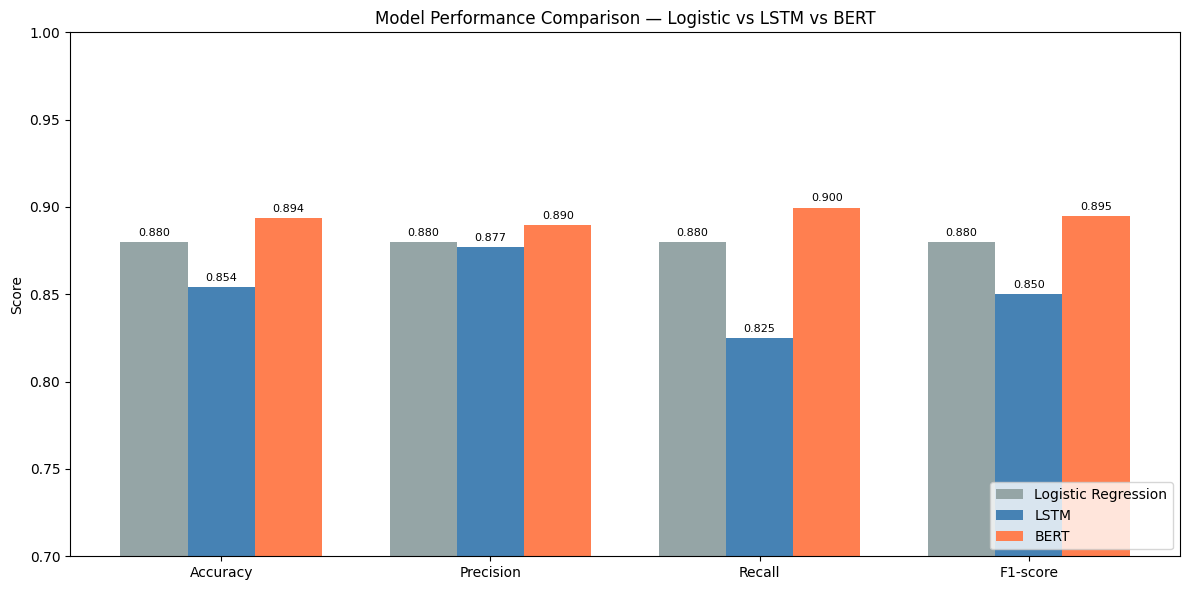

In [101]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Define the metrics and their values from the table
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]

# Values from your dataset
logistic_metrics = {"Accuracy": 0.8800, "Precision": 0.8800, "Recall": 0.8800, "F1-score": 0.8800}
lstm_metrics     = {"Accuracy": 0.8541, "Precision": 0.8770, "Recall": 0.8250, "F1-score": 0.8502}
bert_metrics     = {"Accuracy": 0.8937, "Precision": 0.8897, "Recall": 0.8997, "F1-score": 0.8947}

x = np.arange(len(metrics))
width = 0.25  # Adjusted width for 3 bars

fig, ax = plt.subplots(figsize=(12, 6))

# 2. Create the bars with specific offsets
# Logistic Regression (Left), LSTM (Middle), BERT (Right)
bars1 = ax.bar(x - width, [logistic_metrics[m] for m in metrics],
               width, label="Logistic Regression", color="#95a5a6") # Grayish color

bars2 = ax.bar(x, [lstm_metrics[m] for m in metrics],
               width, label="LSTM", color="steelblue")

bars3 = ax.bar(x + width, [bert_metrics[m] for m in metrics],
               width, label="BERT", color="coral")

# 3. Customizing the plot
ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison — Logistic vs LSTM vs BERT")
ax.set_xticks(x)
ax.set_xticklabels(metrics)

# Setting y-axis limits to highlight the differences
ax.set_ylim(0.7, 1.0)
ax.legend(loc='lower right')

# 4. Adding labels on top of each bar
ax.bar_label(bars1, fmt="%.3f", padding=3, fontsize=8)
ax.bar_label(bars2, fmt="%.3f", padding=3, fontsize=8)
ax.bar_label(bars3, fmt="%.3f", padding=3, fontsize=8)

plt.tight_layout()
plt.savefig("model_comparison_updated.png", dpi=150)
plt.show()

Generating Word Clouds

In [120]:
df1=pd.read_csv('/content/sample_data/processed_text.csv')

In [121]:
df1

,processed_text,sentiment,tokens
0,reviewer mention watch episode youll hook righ...,positive,reviewer mention watch episode youll hook righ...
1,wonderful little production film technique una...,positive,wonderful little production film technique una...
2,think wonderful way spend time hot summer week...,positive,think wonderful way spend time hot summer week...
3,basically family little boy jake think zombie ...,negative,basically family little boy jake think zombie ...
4,petter matteis love time money visually stun f...,positive,petter matteis love time money visually stun f...
...,...,...,...
49577,think movie right good job wasnt creative orig...,positive,think movie right good job wasnt creative orig...
49578,bad plot bad dialogue bad act idiotic direct a...,negative,bad plot bad dialogue bad act idiotic direct a...
49579,catholic teach parochial elementary school nun...,negative,catholic teach parochial elementary school nun...
49580,go disagree previous comment side maltin secon...,negative,go disagree previous comment side maltin secon...


Separting Positive Reviews From Negative Reviews

In [123]:
positive_reviews = df1[df1['sentiment'] == 'positive']['processed_text']
negative_reviews = df1[df1['sentiment'] == 'negative']['processed_text']

Converting All Text Into One Text

In [124]:
positive_text = " ".join(positive_reviews.astype(str))
negative_text = " ".join(negative_reviews.astype(str))

Generating Word Cloud

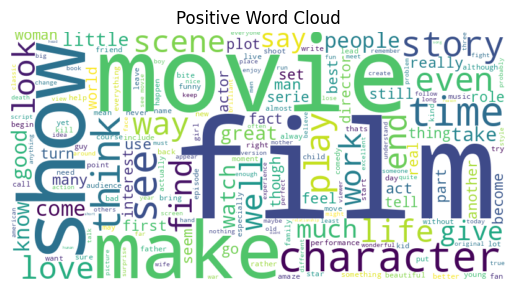

In [125]:
wc_positive = WordCloud(width=800, height=400, background_color='white').generate(positive_text)

plt.imshow(wc_positive, interpolation='bilinear')
plt.axis('off')
plt.title("Positive Word Cloud")
plt.show()

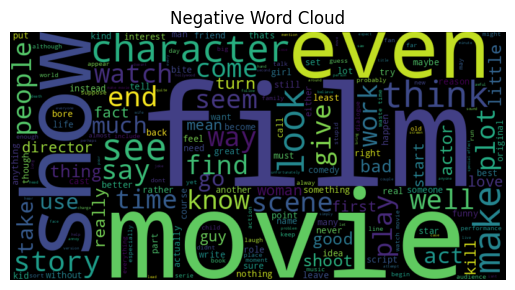

In [126]:
wc_negative = WordCloud(width=800, height=400, background_color='black').generate(negative_text)

plt.imshow(wc_negative, interpolation='bilinear')
plt.axis('off')
plt.title("Negative Word Cloud")
plt.show()

Saving Results As Png File

In [21]:
wc_positive.to_file("wordcloud_positive.png")
wc_negative.to_file("wordcloud_negative.png")

Downloading Files

In [22]:
from google.colab import files

files.download("wordcloud_positive.png")
files.download("wordcloud_negative.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Sentiment Distribution Chart

In [23]:
counts=df1['sentiment'].value_counts()

In [24]:
counts

,count
sentiment,
positive,25000
negative,25000


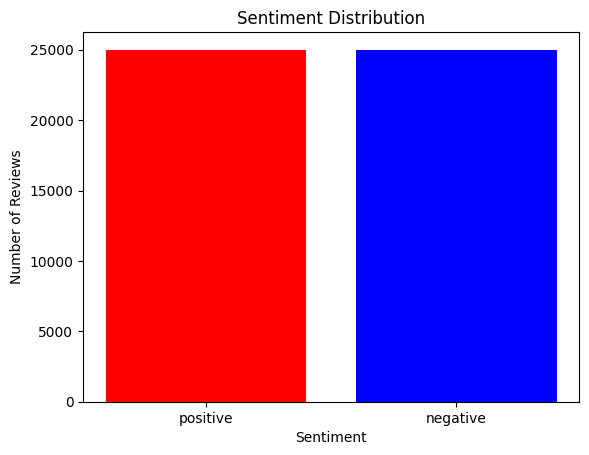

In [119]:

labels = counts.index
values = counts.values
colors = ['red', 'blue']


plt.bar(labels, values, color=colors)


plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

Extracting Top KeyWords Using (Tf,Idf) Vocabulary

Seperating Positive,Negative Reviews

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [28]:
pos_reviews = df1[df1['sentiment'] == 'positive']['review']
neg_reviews = df1[df1['sentiment'] == 'negative']['review']

In [32]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_df=0.7,  # Ignore Words That Appear in more than 70% Of Data
    min_df=5     # Ignore Rare Words (Appear Less Than 5 Times in Data)
)

Extracting Top 3 Unique Keywords For Each Type(positive,Negative)

In [37]:
# 1. Prepare data: Separate your reviews based on sentiment
# Assuming 'df' is your DataFrame and 'review' is the text column
pos_reviews = df1[df1['sentiment'] == 'positive']['review']
neg_reviews = df1[df1['sentiment'] == 'negative']['review']

# 2. Combine all reviews to calculate TF-IDF across the entire dataset
all_reviews = pos_reviews.tolist() + neg_reviews.tolist()

# 3. Initialize TfidfVectorizer
# max_df=0.8 ignores words that appear in more than 80% of the documents (common words)
vectorizer = TfidfVectorizer(stop_words='english', max_df=0.8)
tfidf_matrix = vectorizer.fit_transform(all_reviews)
words = vectorizer.get_feature_names_out()

# 4. Calculate the mean TF-IDF score for each word in each group
# Split the matrix back into positive and negative parts
pos_tfidf_mean = tfidf_matrix[:len(pos_reviews)].mean(axis=0).A1
neg_tfidf_mean = tfidf_matrix[len(pos_reviews):].mean(axis=0).A1

# 5. Calculate the score difference to find 'distinctive' words
# Words with high positive difference are unique to Positive reviews
# Words with high negative difference are unique to Negative reviews
score_difference = pos_tfidf_mean - neg_tfidf_mean

# 6. Get top 3 indices for each category
top_pos_indices = score_difference.argsort()[-3:][::-1]
top_neg_indices = score_difference.argsort()[:3]

# 7. Print the results
print("--- Top 3 Unique Positive Keywords ---")
for i, idx in enumerate(top_pos_indices, 1):
    print(f"{i}. {words[idx]} (Diff Score: {score_difference[idx]:.4f})")

print("\n--- Top 3 Unique Negative Keywords ---")
for i, idx in enumerate(top_neg_indices, 1):
    print(f"{i}. {words[idx]} (Diff Score: {score_difference[idx]:.4f})")

--- Top 3 Unique Positive Keywords ---
1. great (Diff Score: 0.0134)
2. love (Diff Score: 0.0080)
3. best (Diff Score: 0.0075)

--- Top 3 Unique Negative Keywords ---
1. bad (Diff Score: -0.0198)
2. movie (Diff Score: -0.0122)
3. worst (Diff Score: -0.0120)


Model Speed Comparsion Table

In [102]:
# Load data
with open("/content/sample_data/tfidf_vectors.pkl", "rb") as f:
    data = pickle.load(f)

# Extract features and labels
X = data["X"]
y = data["y"]

Train-Test-Split(Logisitc Regression Model)

In [103]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # keeps class balance
)

In [104]:
model = LogisticRegression(max_iter=1000)

In [105]:
# 1. Start the timer
start_time = time.time()

# 2. Train your model (Logistic Regression)
model.fit(X_train, y_train)

# 3. End the timer
end_time = time.time()

# Calculate duration in seconds
duration = end_time - start_time

print(f"Training took: {duration / 60:.2f} minutes")

Training took: 0.01 minutes


lstm

In [106]:
with open("/content/sample_data/word2vec_vectors.pkl", "rb") as f:
   data = pickle.load(f)

X = data["X"]
y = data["y"]

# Check what labels look like
print("Label sample:", y[:5])
print("Label dtype:", y.dtype)

# Fix labels to 0/1
y = (y == "positive").astype(int)


Label sample: ['positive' 'positive' 'positive' 'negative' 'positive']
Label dtype: object


In [107]:
X = X.reshape(X.shape[0], 1, X.shape[1])
print("X reshaped:", X.shape)

X reshaped: (49582, 1, 100)


In [109]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [110]:
model = Sequential([
    LSTM(64, input_shape=(1, X_train.shape[2])),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [111]:
start_time = time.time()

history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)


end_time = time.time()

total_duration = end_time - start_time
print(f"Total Training Time: {total_duration / 60:.2f} minutes")

Epoch 1/10
1116/1116 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8204 - loss: 0.4117 - val_accuracy: 0.8533 - val_loss: 0.3371
Epoch 2/10
1116/1116 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8539 - loss: 0.3442 - val_accuracy: 0.8563 - val_loss: 0.3295
Epoch 3/10
1116/1116 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8567 - loss: 0.3387 - val_accuracy: 0.8586 - val_loss: 0.3254
Epoch 4/10
1116/1116 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8566 - loss: 0.3372 - val_accuracy: 0.8588 - val_loss: 0.3241
Epoch 5/10
1116/1116 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8582 - loss: 0.3344 - val_accuracy: 0.8576 - val_loss: 0.3260
Epoch 6/10
1116/1116 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8565 - loss: 0.3344 - val_accuracy: 0.8624 - val_loss: 0.3212
Epoch 7/10
1116/1116 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8579 - loss: 0.3331 - val_accuracy: 0.8626 - val_loss: 0.3209
Epoch 8/10
1116/1116 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8587 - loss: 0.3332 - 

Bert

In [83]:
df2 = pd.read_csv("/content/sample_data/processed_text.csv")

In [84]:
texts = df2["processed_text"].tolist()
labels_raw = df2["sentiment"].tolist()

label_map = {"positive": 1, "negative": 0,
             "Positive": 1, "Negative": 0}
bert_labels = [label_map[l] if isinstance(l, str) else int(l) for l in labels_raw]

In [90]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

train_texts, test_texts, bert_train_labels, bert_test_labels = train_test_split(
    texts, bert_labels,
    test_size=0.2,
    random_state=42,
    stratify=bert_labels
)

train_encodings = tokenizer(train_texts, truncation=True, padding=True,
                             max_length=128, return_tensors="pt")
test_encodings  = tokenizer(test_texts,  truncation=True, padding=True,
                             max_length=128, return_tensors="pt")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [94]:
class ReviewDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_dataset = ReviewDataset(train_encodings, bert_train_labels)
test_dataset  = ReviewDataset(test_encodings,  bert_test_labels)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=16)

In [96]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

bert_model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)
bert_model.to(device)

Using device: cpu


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [97]:
optimizer = AdamW(bert_model.parameters(), lr=2e-5)

num_epochs = 3
num_training_steps = num_epochs * len(train_loader)

lr_scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps
)

In [98]:
bert_train_acc_history  = []
bert_train_loss_history = []
bert_epoch_times = [] # To store time for each epoch

bert_model.train()

# Start overall timer
overall_start_time = time.time()

for epoch in range(num_epochs):
    epoch_start_time = time.time() # Start epoch timer

    total_loss = 0
    correct = 0
    total = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
    for batch in loop:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = bert_model(**batch)
        loss = outputs.loss
        logits = outputs.logits

        loss.backward()
        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == batch["labels"]).sum().item()
        total += len(batch["labels"])

        loop.set_postfix(loss=loss.item())

    # Calculate metrics
    epoch_loss = total_loss / len(train_loader)
    epoch_acc  = correct / total

    # Calculate time for this epoch
    epoch_duration = time.time() - epoch_start_time
    bert_epoch_times.append(epoch_duration)

    bert_train_loss_history.append(epoch_loss)
    bert_train_acc_history.append(epoch_acc)

    print(f"Epoch {epoch+1} finished in {epoch_duration/60:.2f} minutes. Accuracy: {epoch_acc:.4f}")

# End overall timer
total_duration = time.time() - overall_start_time
print(f"--- Training Complete! Total Time: {total_duration/60:.2f} minutes ---")

Epoch 1/3:   1%|          | 19/2480 [06:40<14:25:19, 21.10s/it, loss=0.641]


KeyboardInterrupt: 

Comparsion

In [112]:
data1 = {
    "Model": ["Logistic Regression", "LSTM", "BERT"],
    "Traning Time":['0.01 Minutes','0.65 Minutes','10 Minutes']
}

In [114]:
df4=pd.DataFrame(data1)

In [115]:
df4

,Model,Traning Time
0,Logistic Regression,0.1 Minutes
1,LSTM,0.65 Minutes
2,BERT,10 Minutes


In [118]:
df4.to_csv("model_speed_table.csv",index=False)